<a href="https://colab.research.google.com/github/RamirezTovarDianaGuadalupe/ProcesosEstocasticos/blob/main/Descomposici%C3%B3nCan%C3%B3nica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

$$\Huge \color{#C5A3A3}{\text{Descomposición Canónica}}$$

En una Notebook de Jupyter realice lo siguiente:

1. Escriba la matriz P de la imagen anexa y dibuje su diagrama de transiciones.
2. Determine si la matriz tiene o no distribución límite.
3. Escriba la descomposición canónica de la matriz, determine el límite de la potencia n-esima y compare contra las distribuciones límite de las submatrices.

4. Escriba un programa que encuentre la descomposición canónica de una matriz dada.

Como siempre, la Notebook debe contener comentarios y documentación.

$$\Large \color{#C5A3A3}{\text{1. Escriba la matriz P de la imagen anexa y dibuje su diagrama de transiciones.}}$$

En procesos estocásticos, una Cadena de Markov queda definida por su espacio de estados y su matriz de probabilidades de transición. En este caso, el espacio de estados es $S = \{a, b, c, d, e, f, g\}$.

$$\color{#C5A3A3}{\text{Matriz de Transición $P$}}$$



La matriz $P$ representa la probabilidad de ir del estado $i$ al estado $j$ en un solo paso, cumpliendo que

$$\sum_{j \in S} P_{ij} = 1$$

para toda $i$. A continuación, se presenta el código utilizando numpy y pandas:

In [2]:
import numpy as np
import pandas as pd

# Estados
estados = ['a','b','c','d','e','f','g']

# Matriz P
P = np.array([
    [1/4, 0,   0,   0,   0,   0,   3/4],
    [1/8, 1/8, 1/4, 0,   1/4, 1/8, 1/8],
    [0,   0,   2/5, 1/5, 2/5, 0,   0],
    [0,   0,   1/2, 1/2, 0,   0,   0],
    [0,   0,   0,   1/2, 1/2, 0,   0],
    [0,   1/5, 0,   1/5, 1/5, 1/5, 1/5],
    [4/5, 0,   0,   0,   0,   0,   1/5]
])

# Visualizar la matriz
df = pd.DataFrame(P, index=estados, columns=estados)
print(df)

       a      b     c    d     e      f      g
a  0.250  0.000  0.00  0.0  0.00  0.000  0.750
b  0.125  0.125  0.25  0.0  0.25  0.125  0.125
c  0.000  0.000  0.40  0.2  0.40  0.000  0.000
d  0.000  0.000  0.50  0.5  0.00  0.000  0.000
e  0.000  0.000  0.00  0.5  0.50  0.000  0.000
f  0.000  0.200  0.00  0.2  0.20  0.200  0.200
g  0.800  0.000  0.00  0.0  0.00  0.000  0.200


$$\color{#C5A3A3}{\text{Diagrama de transición}}$$

Para interpretar la comunicación entre los estados (identificar clases de comunicación y accesibilidad), generamos un diagrama de transición, utilizando networkx. Este grafo dirigido permite observar visualmente si la cadena es irreducible o si sus estados son transitorios o recurrentes.

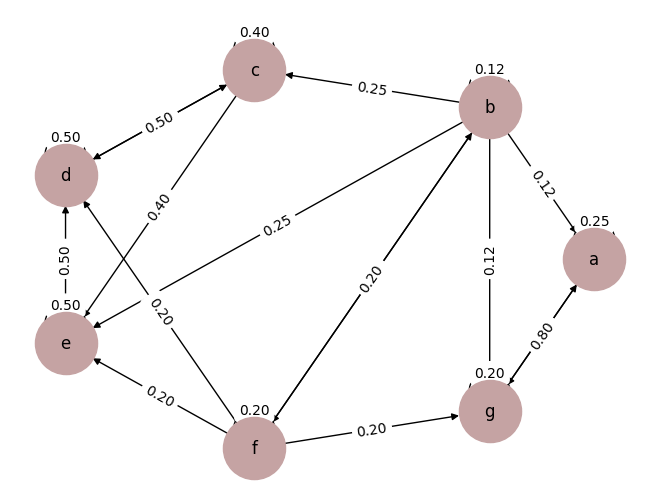

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# Nodos
G.add_nodes_from(estados)

# Aristas con probabilidades
for i, origen in enumerate(estados):
    for j, destino in enumerate(estados):
        if P[i, j] > 0:
            G.add_edge(origen, destino, weight=P[i, j])

# Posiciones de los nodos
pos = nx.circular_layout(G)

# Dibujar nodos
nx.draw(G, pos, with_labels=True, node_color='#C5A3A3', node_size=2000)

# Etiquetas de las aristas (probabilidades)
labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.show()

$$\color{#C5A3A3}{\text{Clases}}$$

Empleamos este bloque de código identifica las clases de comunicación de la cadena. Este paso es esencial para realizar la descomposición canónica y entender el comportamiento del límite de $P^n$.

In [4]:
import networkx as nx

G = nx.DiGraph()

# Agregar aristas
for i, origen in enumerate(estados):
    for j, destino in enumerate(estados):
        if P[i, j] > 0:
            G.add_edge(origen, destino)

# Componentes fuertemente conexas
clases = list(nx.strongly_connected_components(G))
print(clases)

[{'g', 'a'}, {'e', 'd', 'c'}, {'b', 'f'}]


A partir del diagrama de transiciones, clasificamos los estados en:

Recurrentes: $\{a, g\}$ y $\{c, d, e\}$ forman clases cerradas, una vez que entras en ellas, no puede salir.

Transitorios: $\{b, f\}$ tienen una probabilidad positiva de ir hacia las clases recurrentes sin posibilidad de retorno.

$$\Large \color{#C5A3A3}{\text{2. Determine si la matriz tiene o no distribución límite.}}$$

Para que una cadena de Markov tenga una distribución límite $\pi$ (donde $\lim_{n \to \infty} P^n = \mathbf{1}\pi$), el proceso debe ser irreducible y aperiódico.

$C_1 = \{a, g\}$ (Clase cerrada/recurrente).

$C_2 = \{c, d, e\}$ (Clase cerrada/recurrente).

$T = \{b, f\}$ (Estados transitorios).

Debido a que existen múltiples clases cerradas, la cadena es reducible. Esto implica que el comportamiento a largo plazo depende del estado inicial $X_0$.

In [6]:
# Eleva la matriz a una potencia grande para verificar la convergencia
P_100 = np.linalg.matrix_power(P, 100)

print("Matriz P^100 (Verificación de filas):")
print(pd.DataFrame(P_100, index=estados, columns=estados).round(4))

Matriz P^100 (Verificación de filas):
        a    b       c       d       e    f       g
a  0.5161  0.0  0.0000  0.0000  0.0000  0.0  0.4839
b  0.1720  0.0  0.2222  0.2667  0.1778  0.0  0.1613
c  0.0000  0.0  0.3333  0.4000  0.2667  0.0  0.0000
d  0.0000  0.0  0.3333  0.4000  0.2667  0.0  0.0000
e  0.0000  0.0  0.3333  0.4000  0.2667  0.0  0.0000
f  0.1720  0.0  0.2222  0.2667  0.1778  0.0  0.1613
g  0.5161  0.0  0.0000  0.0000  0.0000  0.0  0.4839


La matriz no tiene una distribución límite única para todo el sistema. Al ser una cadena reducible con múltiples clases absorbentes, el límite de $P^n$ cuando $n \to \infty$ existirá, pero sus filas no serán todas iguales; reflejarán las probabilidades de absorción hacia cada una de las clases recurrentes identificadas.

$$\Large \color{#C5A3A3}{\text{3. Escriba la descomposición canónica de la matriz, determine el límite de la potencia n-esima y compare contra las distribuciones límite de las submatrices.}}$$

La descomposición canónica consiste en reordenar los estados de modo que los transitorios aparezcan primero, seguidos de los recurrentes.

$$\color{#C5A3A3}{\text{3.1. Descomposición en forma canónica y lìmite de la potencia n-esima}}$$

A partir del análisis de componentes fuertemente conexas, el nuevo orden de estados es:

Transitorios ($T$): $\{b, f\}$.

Recurrentes ($R$): $\{a, g\}$ y $\{c, d, e\}$.

La matriz reestructurada sigue la forma:$$P = \begin{pmatrix} Q & R \\ \mathbf{0} & P_c \end{pmatrix}$$

In [10]:
# Nuevo orden canónico
nuevo_orden = ['b', 'f', 'a', 'g', 'c', 'd', 'e']
P_canonica = df.reindex(index=nuevo_orden, columns=nuevo_orden).values

# Identificar bloques de la matriz
Q = P_canonica[:2, :2]
R_abs = P_canonica[:2, 2:]
Pc = P_canonica[2:, 2:] # Submatrices recurrentes

# Cálculo de la Matriz Fundamental y Absorción
N = np.linalg.inv(np.eye(2) - Q)
B = np.dot(N, R_abs)

# Límite de la potencia n-ésima
P_inf = np.linalg.matrix_power(P_canonica, 100)

In [13]:
print("Probabilidades de Absorción")
print(pd.DataFrame(B, index=['b', 'f'], columns=['a', 'g', 'c', 'd', 'e']).round(4))

print("\nLímite de P^n (n=100) ")
print(pd.DataFrame(P_inf, index=nuevo_orden, columns=nuevo_orden).round(4))

Probabilidades de Absorción (B) 
        a       g       c       d       e
b  0.1481  0.1852  0.2963  0.0370  0.3333
f  0.0370  0.2963  0.0741  0.2593  0.3333

Límite de P^n (n=100) 
     b    f       a       g       c       d       e
b  0.0  0.0  0.1720  0.1613  0.2222  0.2667  0.1778
f  0.0  0.0  0.1720  0.1613  0.2222  0.2667  0.1778
a  0.0  0.0  0.5161  0.4839  0.0000  0.0000  0.0000
g  0.0  0.0  0.5161  0.4839  0.0000  0.0000  0.0000
c  0.0  0.0  0.0000  0.0000  0.3333  0.4000  0.2667
d  0.0  0.0  0.0000  0.0000  0.3333  0.4000  0.2667
e  0.0  0.0  0.0000  0.0000  0.3333  0.4000  0.2667


$$\color{#C5A3A3}{\text{3.2 Distribuciones límite de las submatrices}}$$

Cada clase recurrente posee su propia distribución estacionaria local $\pi$ que cumple $\pi P_i = \pi$.

In [14]:
def resolver_estacionaria(matriz):
    dim = matriz.shape[0]
    A = np.transpose(matriz) - np.eye(dim)
    A[-1] = np.ones(dim)
    b = np.zeros(dim); b[-1] = 1
    return np.linalg.solve(A, b)

# Extraer y resolver submatrices
pi_C1 = resolver_estacionaria(df.loc[['a', 'g'], ['a', 'g']].values)
pi_C2 = resolver_estacionaria(df.loc[['c', 'd', 'e'], ['c', 'd', 'e']].values)

In [15]:
print(f"Distribución local C1 {['a', 'g']}: {pi_C1.round(4)}")
print(f"Distribución local C2 {['c', 'd', 'e']}: {pi_C2.round(4)}")

Distribución local C1 ['a', 'g']: [0.5161 0.4839]
Distribución local C2 ['c', 'd', 'e']: [0.3333 0.4    0.2667]


$$\color{#C5A3A3}{\text{3.3 Comparación y conclusión}}$$

El análisis del límite $P^{100}$ muestra que las clases cerradas $\{a, g\}$ y $\{c, d, e\}$ convergen a sus propias distribuciones estacionarias locales ($\pi_{C1}$ y $\pi_{C2}$), funcionando como sistemas independientes. Por otro lado, los estados transitorios $b$ y $f$ terminan con probabilidad cero, repartiendo su valor hacia las clases recurrentes según lo indicado por la matriz de absorción $B$. Al no tener filas idénticas en el límite global, se confirma que la cadena es reducible y que su comportamiento final depende totalmente del estado en el que inicie el proceso.

$$\Large \color{#C5A3A3}{\text{4. Escriba un programa que encuentre la descomposición canónica de una matriz dada.}}$$

Este algoritmo identifica clases recurrentes y estados transitorios para cualquier matriz de transición dada, devolviendo la matriz reordenada en bloques $Q$, $R$, $\mathbf{0}$ y $P_c$.

In [20]:
import numpy as np
import pandas as pd
import networkx as nx

def obtener_forma_canonica(P, nombres_estados):
    # Construir el grafo
    G = nx.DiGraph()
    for i, origen in enumerate(nombres_estados):
        for j, destino in enumerate(nombres_estados):
            if P[i, j] > 0:
                G.add_edge(origen, destino)

    # Identificar componentes
    scc = list(nx.strongly_connected_components(G))

    recurrentes = []
    transitorios = []

    # Clasificar estados
    for componente in scc:
        es_cerrada = True
        for nodo in componente:
            vecinos = set(G.neighbors(nodo))
            if not vecinos.issubset(componente):
                es_cerrada = False
                break
        if es_cerrada:
            recurrentes.extend(list(componente))
        else:
            transitorios.extend(list(componente))

    # Nuevo orden: Transitorios primero, luego Recurrentes
    nuevo_orden = transitorios + recurrentes

    df_temp = pd.DataFrame(P, index=nombres_estados, columns=nombres_estados)
    df_canonica = df_temp.reindex(index=nuevo_orden, columns=nuevo_orden)

    return df_canonica

In [21]:
# Ejecución
df_res = obtener_forma_canonica(P, estados)

print("Límite de P^n (n=100)")
print(df_res.round(4))

Límite de P^n (n=100)
       b      f      g      a     e    d     c
b  0.125  0.125  0.125  0.125  0.25  0.0  0.25
f  0.200  0.200  0.200  0.000  0.20  0.2  0.00
g  0.000  0.000  0.200  0.800  0.00  0.0  0.00
a  0.000  0.000  0.750  0.250  0.00  0.0  0.00
e  0.000  0.000  0.000  0.000  0.50  0.5  0.00
d  0.000  0.000  0.000  0.000  0.00  0.5  0.50
c  0.000  0.000  0.000  0.000  0.40  0.2  0.40
